# RQ3b — Self-Reflection Intervention
Uses Round 3 (`judgment_after_reflection`) as the final answer. Compares R1→R3 against RQ1 base (R1→R2).

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import json
from pathlib import Path
from collections import defaultdict

RQ3B_DIR = Path("../results_todos/rq3b")
RQ1_DIR  = Path("../results_todos/rq1")

RQ1_CONDITIONS = [
    "all_correct_absent", "all_correct_present",
    "mixed_absent",       "mixed_present",
    "all_wrong_absent",   "all_wrong_present",
]
CONDITION_LABELS = {
    "all_correct_absent":  "All-correct\n(no auth)",
    "all_correct_present": "All-correct\n(auth)",
    "mixed_absent":        "Mixed\n(no auth)",
    "mixed_present":       "Mixed\n(auth)",
    "all_wrong_absent":    "All-wrong\n(no auth)",
    "all_wrong_present":   "All-wrong\n(auth)",
}

def dataset_of(path):
    """Classify a file as in-distribution (primevul) or out-of-distribution (ood_benchmark)."""
    name = path.name
    if "ood_benchmark" in name:
        return "ood"
    if "primevul" in name:
        return "id"
    return None

def compute_rq3b_metrics(jsonl_path):
    """
    Computes metrics using judgment_after_reflection (R3) as final answer.
    - revised_r2: R1 -> R2 change (did peers cause revision in round 2?)
    - revised_r3: R1 -> R3 net change (did the model end up different from start?)
    - harmful/beneficial: based on R1 -> R3 net outcome.
    - FIX: confidence_after_reflection is NOT fallen back to confidence_after.
      Rows missing R3 confidence are skipped entirely to avoid mixing metrics.
    """
    buckets = defaultdict(lambda: {
        "n": 0, "r1": 0, "r3": 0,
        "revised_r2": 0, "revised_r3": 0,
        "cb_n": 0, "harmful": 0, "wb_n": 0, "beneficial": 0, "dc": []
    })
    skipped = 0
    with open(jsonl_path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line: continue
            row = json.loads(line)
            gold = row["answer"]["label"]
            a0 = row.get("judgment_before")
            a2 = row.get("judgment_after")
            a3 = row.get("judgment_after_reflection")
            c0 = row.get("confidence_before")
            # FIX: do NOT fall back to confidence_after — skip if R3 confidence missing
            c3 = row.get("confidence_after_reflection")
            cond = row.get("condition_id", "unknown")
            if any(v is None for v in [a0, a3, c0, c3]):
                skipped += 1
                continue
            b = buckets[cond]
            b["n"] += 1
            r1_ok = (a0 == gold)
            r3_ok = (a3 == gold)
            if r1_ok: b["r1"] += 1
            if r3_ok: b["r3"] += 1
            if a2 is not None and a2 != a0: b["revised_r2"] += 1
            if a3 != a0: b["revised_r3"] += 1
            if r1_ok:
                b["cb_n"] += 1
                if not r3_ok: b["harmful"] += 1
            else:
                b["wb_n"] += 1
                if r3_ok: b["beneficial"] += 1
            b["dc"].append(c3 - c0)
    return buckets, skipped

def pct(n, d): return round(100*n/d, 2) if d > 0 else None
def mn(v): return round(sum(v)/len(v), 4) if v else None

rows_id, rows_ood = [], []
for jsonl_path in sorted(RQ3B_DIR.rglob("*.jsonl")):
    dataset = dataset_of(jsonl_path)
    if dataset is None:
        continue
    with open(jsonl_path, encoding="utf-8") as f:
        first = f.readline()
    if "judgment_after_reflection" not in first: continue
    parts = jsonl_path.parts
    try:
        seed_idx = next(i for i, p in enumerate(parts) if p.startswith("seed_"))
        seed = parts[seed_idx].replace("seed_", "")
        model = parts[seed_idx - 1]
    except: continue
    buckets, skipped = compute_rq3b_metrics(jsonl_path)
    print(f"{model} seed_{seed} ({dataset}): {skipped} rows skipped (missing R3 confidence)")
    rows_target = rows_id if dataset == "id" else rows_ood
    for cond, b in buckets.items():
        if cond not in RQ1_CONDITIONS: continue
        rows_target.append({
            "model": model, "seed": seed, "condition": cond,
            "n": b["n"],
            "acc_r1": pct(b["r1"], b["n"]),
            "acc_r3": pct(b["r3"], b["n"]),
            "delta_acc": round((b["r3"]-b["r1"])/b["n"]*100, 2) if b["n"] else None,
            "rev_pct_r2": pct(b["revised_r2"], b["n"]),
            "rev_pct_r3": pct(b["revised_r3"], b["n"]),
            "harm_pct": pct(b["harmful"], b["cb_n"]),
            "ben_pct": pct(b["beneficial"], b["wb_n"]),
            "mean_dC": mn(b["dc"]),
        })

def group_rows(rows):
    df = pd.DataFrame(rows)
    return df.groupby(["model", "condition"]).mean(numeric_only=True).reset_index() if not df.empty else df

combined = group_rows(rows_id)
combined_ood = group_rows(rows_ood)

def load_rq1(rq1_dir):
    """Returns (id_df, ood_df) grouped/averaged over seeds, split by dataset."""
    id_dfs, ood_dfs = [], []
    for csv_path in sorted(rq1_dir.rglob("*.metrics.csv")):
        if "primevul_dataset" in csv_path.name or "_all_seeds" in csv_path.name:
            continue
        parts = csv_path.parts
        if not any(p.startswith("seed_") for p in parts): continue
        dataset = dataset_of(csv_path)
        if dataset is None:
            continue
        df = pd.read_csv(csv_path)
        df = df[df["condition"].isin(RQ1_CONDITIONS)]
        if df.empty: continue
        (id_dfs if dataset == "id" else ood_dfs).append(df)

    def group(dfs):
        all_df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
        return all_df.groupby(["model", "condition"]).mean(numeric_only=True).reset_index() if not all_df.empty else pd.DataFrame()

    return group(id_dfs), group(ood_dfs)

rq1, rq1_ood = load_rq1(RQ1_DIR)
MODELS = sorted(combined["model"].unique()) if not combined.empty else sorted(rq1["model"].unique())
PALETTE = sns.color_palette("tab10", len(MODELS))
MODEL_COLORS = dict(zip(MODELS, PALETTE))

print(f"\nModels: {MODELS}")
print(f"In-distribution (primevul) conditions: {sorted(combined['condition'].unique()) if not combined.empty else 'no ID jsonl data found'}")
print(f"Out-of-distribution (ood_benchmark) conditions: "
      f"{sorted(combined_ood['condition'].unique()) if not combined_ood.empty else 'no OOD jsonl data found'}")


llama31_it seed_42 (ood): 0 rows skipped (missing R3 confidence)
llama31_it seed_42 (id): 0 rows skipped (missing R3 confidence)
llama31_it seed_43 (ood): 0 rows skipped (missing R3 confidence)
llama31_it seed_43 (id): 0 rows skipped (missing R3 confidence)
llama31_it seed_44 (ood): 0 rows skipped (missing R3 confidence)
llama31_it seed_44 (id): 0 rows skipped (missing R3 confidence)
mistral_it seed_42 (ood): 6 rows skipped (missing R3 confidence)
mistral_it seed_42 (id): 2 rows skipped (missing R3 confidence)
mistral_it seed_43 (ood): 3 rows skipped (missing R3 confidence)
mistral_it seed_43 (id): 3 rows skipped (missing R3 confidence)
mistral_it seed_44 (ood): 4 rows skipped (missing R3 confidence)
mistral_it seed_44 (id): 3 rows skipped (missing R3 confidence)
phi35_it seed_42 (ood): 0 rows skipped (missing R3 confidence)
phi35_it seed_42 (id): 0 rows skipped (missing R3 confidence)
phi35_it seed_43 (ood): 0 rows skipped (missing R3 confidence)
phi35_it seed_43 (id): 0 rows skipped 

## Per-model tables (Self-reflect, Round 1 vs Round 3)

> **rev_pct_r2** = % of instances where the model revised in Round 2 (after seeing peers). **rev_pct_r3** = % where the net R1→R3 answer differs. A model that revised in R2 but then reverted in R3 contributes to rev_pct_r2 but NOT rev_pct_r3.

In [15]:
display_cols = ["condition", "n", "acc_r1", "acc_r3", "delta_acc",
                "rev_pct_r2", "rev_pct_r3", "harm_pct", "ben_pct", "mean_dC"]

for model in MODELS:
    df_m = combined[(combined["model"] == model) & (combined["condition"].isin(RQ1_CONDITIONS))].copy()
    present = [c for c in RQ1_CONDITIONS if c in df_m["condition"].values]
    df_m["condition"] = pd.Categorical(df_m["condition"], categories=present, ordered=True)
    df_m = df_m.sort_values("condition")
    avail = [c for c in display_cols if c in df_m.columns]
    df_m = df_m[avail].reset_index(drop=True)
    fmt_cols = [c for c in ["acc_r1","acc_r3","delta_acc","rev_pct_r2","rev_pct_r3","harm_pct","ben_pct","mean_dC"] if c in df_m.columns]
    print(f"\n{'─'*60}\n  {model.upper()} — Self-Reflect\n{'─'*60}")
    display(df_m.style
        .format({"n": lambda x: f"{int(x)}" if pd.notna(x) and x == int(x) else (f"{x:.2f}" if pd.notna(x) else "N/A"),
                 **{c: "{:.1f}" for c in fmt_cols}}, na_rep="N/A")
        .background_gradient(subset=["delta_acc"], cmap="RdYlGn", vmin=-30, vmax=30)
        .background_gradient(subset=["harm_pct"],  cmap="Reds",   vmin=0,   vmax=100)
        .background_gradient(subset=["ben_pct"],   cmap="Greens", vmin=0,   vmax=100)
        .set_caption(f"{model} Self-Reflect"))



────────────────────────────────────────────────────────────
  LLAMA31_IT — Self-Reflect
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r3,delta_acc,rev_pct_r2,rev_pct_r3,harm_pct,ben_pct,mean_dC
0,all_correct_absent,500,53.1,75.9,22.8,34.3,29.2,6.0,55.5,-0.0
1,all_correct_present,500,53.1,76.9,23.8,34.6,29.3,5.1,56.6,0.1
2,mixed_absent,500,53.1,52.0,-1.1,27.5,61.4,58.8,64.3,0.1
3,mixed_present,500,53.1,49.7,-3.4,30.9,57.5,57.3,57.8,0.0
4,all_wrong_absent,500,53.1,21.8,-31.3,28.3,39.1,66.3,8.3,0.0
5,all_wrong_present,500,53.1,24.4,-28.7,31.7,34.1,59.1,5.7,0.2



────────────────────────────────────────────────────────────
  MISTRAL_IT — Self-Reflect
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r3,delta_acc,rev_pct_r2,rev_pct_r3,harm_pct,ben_pct,mean_dC
0,all_correct_absent,500,56.3,54.1,-2.2,25.7,20.7,20.4,21.2,0.7
1,all_correct_present,499.67,56.2,57.3,1.1,28.8,22.9,19.5,27.4,0.4
2,mixed_absent,498.33,56.3,55.7,-0.6,2.9,3.1,3.3,2.9,0.5
3,mixed_present,499.67,56.3,54.8,-1.5,5.8,6.3,6.9,5.5,0.7
4,all_wrong_absent,500,56.3,51.9,-4.4,33.0,27.3,28.2,26.2,0.5
5,all_wrong_present,499.67,56.3,49.4,-6.9,37.5,30.4,33.2,26.9,0.5



────────────────────────────────────────────────────────────
  PHI35_IT — Self-Reflect
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r3,delta_acc,rev_pct_r2,rev_pct_r3,harm_pct,ben_pct,mean_dC
0,all_correct_absent,500,50.4,54.3,3.9,16.7,12.3,8.3,16.4,0.1
1,all_correct_present,500,50.4,62.1,11.7,30.9,18.7,7.0,30.6,0.0
2,mixed_absent,500,50.4,49.9,-0.5,1.9,33.5,33.7,33.2,0.0
3,mixed_present,500,50.4,50.1,-0.3,7.9,36.3,36.4,36.3,0.0
4,all_wrong_absent,500,50.4,45.2,-5.2,20.4,8.0,13.1,2.8,0.1
5,all_wrong_present,500,50.4,37.3,-13.1,35.0,16.8,29.6,3.8,0.1



────────────────────────────────────────────────────────────
  QWEN25_IT — Self-Reflect
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r3,delta_acc,rev_pct_r2,rev_pct_r3,harm_pct,ben_pct,mean_dC
0,all_correct_absent,500,60.6,81.9,21.3,43.9,37.9,13.6,75.1,0.9
1,all_correct_present,500,60.6,83.6,23.0,44.1,36.7,11.3,75.8,0.8
2,mixed_absent,500,60.6,51.6,-9.0,37.8,35.1,36.4,33.2,0.7
3,mixed_present,500,60.6,52.7,-7.9,39.9,36.4,36.5,36.2,0.6
4,all_wrong_absent,500,60.6,25.0,-35.6,64.2,50.0,70.6,18.3,0.8
5,all_wrong_present,500,60.6,21.1,-39.5,64.1,53.4,76.7,17.6,0.8


## Self-Reflect vs Base: Δ Accuracy comparison

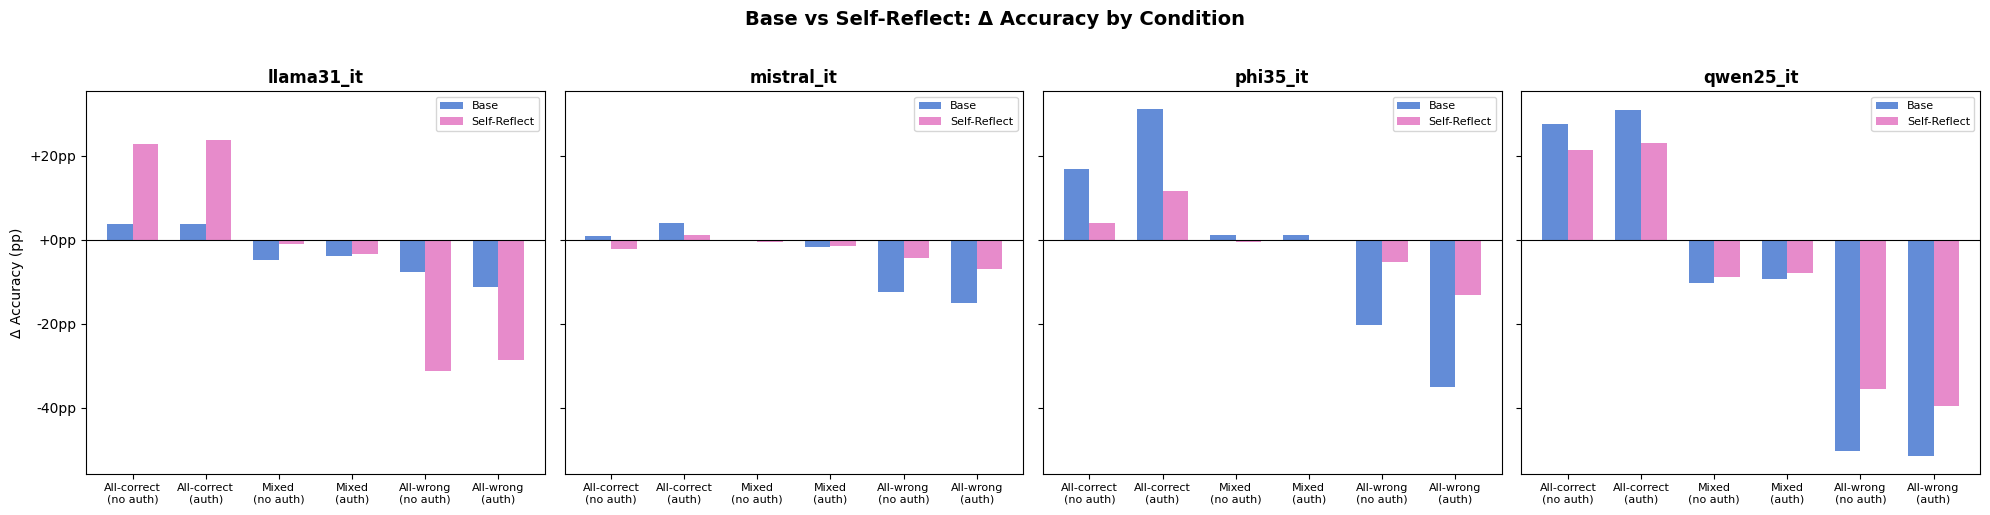

In [16]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(5*len(MODELS), 5), sharey=True)
if len(MODELS) == 1:
    axes = [axes]

for ax, model in zip(axes, MODELS):
    for df, label, color in [(rq1, "Base", "#4878d0"), (combined, "Self-Reflect", "#e377c2")]:
        df_m = df[(df["model"] == model) & (df["condition"].isin(RQ1_CONDITIONS))].copy()
        p = [c for c in RQ1_CONDITIONS if c in df_m["condition"].values]
        df_m["condition"] = pd.Categorical(df_m["condition"], categories=p, ordered=True)
        df_m = df_m.sort_values("condition")
        x = range(len(df_m))
        offset = -0.175 if label == "Base" else 0.175
        ax.bar([i + offset for i in x], df_m["delta_acc"], 0.35, label=label, color=color, alpha=0.85)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(model, fontsize=12, fontweight="bold")
    ax.set_xticks(list(range(len(p))))
    ax.set_xticklabels([CONDITION_LABELS.get(c, c) for c in p], fontsize=8)
    ax.set_ylabel("\u0394 Accuracy (pp)" if ax == axes[0] else "")
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:+.0f}pp"))

plt.suptitle("Base vs Self-Reflect: \u0394 Accuracy by Condition", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(RQ3B_DIR / "rq3b_selfreflect_vs_base.png", dpi=150, bbox_inches="tight")
plt.show()


## Δ Accuracy heatmap — Self-Reflect across models × conditions

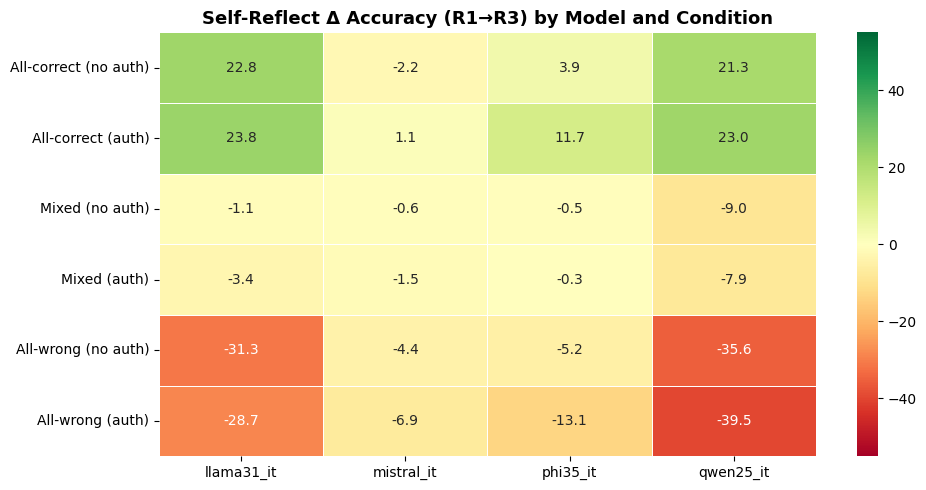

In [17]:
pivot = combined[combined["condition"].isin(RQ1_CONDITIONS)].pivot_table(
    index="condition", columns="model", values="delta_acc")
pivot = pivot.reindex([c for c in RQ1_CONDITIONS if c in pivot.index])

fig, ax = plt.subplots(figsize=(max(6, 2.5*len(MODELS)), 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0, vmin=-55, vmax=55,
            linewidths=0.5, ax=ax, annot_kws={"size": 10})
ax.set_title("Self-Reflect \u0394 Accuracy (R1\u2192R3) by Model and Condition", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_yticklabels([CONDITION_LABELS.get(c, c).replace("\n", " ") for c in pivot.index], rotation=0)
plt.tight_layout()
plt.savefig(RQ3B_DIR / "rq3b_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


# Out-of-Distribution (OOD) Results

Repeats the self-reflection analysis above on the `ood_benchmark_rq1_rq3` raw outputs (both for RQ3b self-reflect and the RQ1 baseline), to check whether self-reflection's effect on peer-conformity resistance generalizes beyond the in-distribution (ID) dataset.

## Per-model tables (Self-reflect, Round 1 vs Round 3) — OOD

In [18]:
if combined_ood.empty:
    print("No OOD data found.")
else:
    display_cols = ["condition", "n", "acc_r1", "acc_r3", "delta_acc",
                    "rev_pct_r2", "rev_pct_r3", "harm_pct", "ben_pct", "mean_dC"]

    for model in MODELS:
        df_m = combined_ood[(combined_ood["model"] == model) & (combined_ood["condition"].isin(RQ1_CONDITIONS))].copy()
        present = [c for c in RQ1_CONDITIONS if c in df_m["condition"].values]
        df_m["condition"] = pd.Categorical(df_m["condition"], categories=present, ordered=True)
        df_m = df_m.sort_values("condition")
        avail = [c for c in display_cols if c in df_m.columns]
        df_m = df_m[avail].reset_index(drop=True)
        fmt_cols = [c for c in ["acc_r1","acc_r3","delta_acc","rev_pct_r2","rev_pct_r3","harm_pct","ben_pct","mean_dC"] if c in df_m.columns]
        print(f"\n{'─'*60}\n  {model.upper()} — Self-Reflect, OOD\n{'─'*60}")
        display(df_m.style
            .format({"n": lambda x: f"{int(x)}" if pd.notna(x) and x == int(x) else (f"{x:.2f}" if pd.notna(x) else "N/A"),
                     **{c: "{:.1f}" for c in fmt_cols}}, na_rep="N/A")
            .background_gradient(subset=["delta_acc"], cmap="RdYlGn", vmin=-30, vmax=30)
            .background_gradient(subset=["harm_pct"],  cmap="Reds",   vmin=0,   vmax=100)
            .background_gradient(subset=["ben_pct"],   cmap="Greens", vmin=0,   vmax=100)
            .set_caption(f"{model} Self-Reflect — OOD"))



────────────────────────────────────────────────────────────
  LLAMA31_IT — Self-Reflect, OOD
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r3,delta_acc,rev_pct_r2,rev_pct_r3,harm_pct,ben_pct,mean_dC
0,all_correct_absent,500,52.7,74.7,21.9,36.1,33.1,10.6,58.2,0.0
1,all_correct_present,500,52.7,72.1,19.4,39.1,28.3,8.5,50.5,0.1
2,mixed_absent,500,52.7,51.9,-0.9,31.9,60.9,58.5,63.5,0.3
3,mixed_present,500,52.7,51.0,-1.7,34.2,58.1,56.8,59.7,0.2
4,all_wrong_absent,500,52.7,23.7,-29.1,31.9,35.3,61.1,6.6,0.0
5,all_wrong_present,500,52.7,24.7,-28.0,33.1,34.7,59.4,7.0,0.3



────────────────────────────────────────────────────────────
  MISTRAL_IT — Self-Reflect, OOD
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r3,delta_acc,rev_pct_r2,rev_pct_r3,harm_pct,ben_pct,mean_dC
0,all_correct_absent,498.67,54.1,52.2,-1.9,21.2,20.0,20.2,19.7,0.4
1,all_correct_present,500,54.0,52.2,-1.8,24.7,22.6,22.6,22.6,0.3
2,mixed_absent,499.67,54.0,54.6,0.6,1.0,2.6,1.9,3.5,0.5
3,mixed_present,499,54.0,53.0,-0.9,5.7,6.0,6.4,5.5,0.7
4,all_wrong_absent,499,54.1,52.2,-1.9,26.4,24.6,24.4,24.7,0.5
5,all_wrong_present,499.33,54.1,50.1,-3.9,27.2,24.5,26.3,22.4,0.6



────────────────────────────────────────────────────────────
  PHI35_IT — Self-Reflect, OOD
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r3,delta_acc,rev_pct_r2,rev_pct_r3,harm_pct,ben_pct,mean_dC
0,all_correct_absent,500,50.2,56.3,6.1,14.9,10.8,4.6,17.0,0.1
1,all_correct_present,500,50.2,63.2,13.0,31.1,17.5,4.5,30.7,0.1
2,mixed_absent,500,50.2,50.1,-0.1,1.6,33.4,33.3,33.5,0.0
3,mixed_present,500,50.2,50.9,0.7,7.0,38.5,37.6,39.4,0.0
4,all_wrong_absent,500,50.2,44.2,-6.0,17.9,9.2,15.1,3.2,0.1
5,all_wrong_present,500,50.2,39.3,-10.9,28.9,15.8,26.6,5.0,0.1



────────────────────────────────────────────────────────────
  QWEN25_IT — Self-Reflect, OOD
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r3,delta_acc,rev_pct_r2,rev_pct_r3,harm_pct,ben_pct,mean_dC
0,all_correct_absent,500,57.3,82.5,25.2,47.3,36.9,10.2,72.8,0.8
1,all_correct_present,500,57.3,88.7,31.3,44.9,37.3,5.2,80.5,0.8
2,mixed_absent,500,57.3,51.7,-5.7,38.9,36.1,36.4,35.6,0.7
3,mixed_present,500,57.3,49.9,-7.5,38.0,34.3,36.4,31.4,0.6
4,all_wrong_absent,500,57.3,19.5,-37.9,58.7,45.9,73.0,9.4,0.8
5,all_wrong_present,500,57.3,15.5,-41.9,58.1,47.5,77.9,6.6,0.8


## Self-Reflect vs Base: Δ Accuracy comparison — OOD

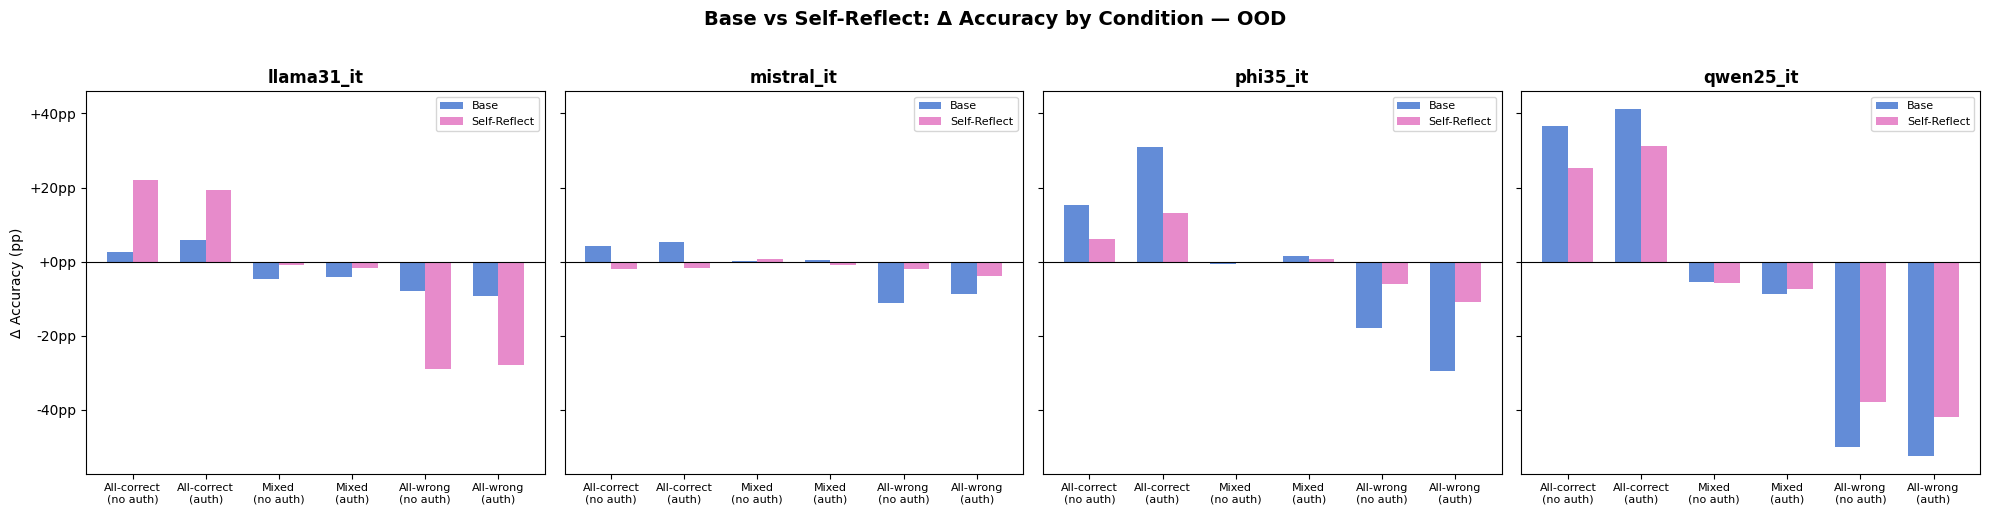

In [19]:
if combined_ood.empty or rq1_ood.empty:
    print("No OOD data found.")
else:
    fig, axes = plt.subplots(1, len(MODELS), figsize=(5*len(MODELS), 5), sharey=True)
    if len(MODELS) == 1:
        axes = [axes]

    for ax, model in zip(axes, MODELS):
        for df, label, color in [(rq1_ood, "Base", "#4878d0"), (combined_ood, "Self-Reflect", "#e377c2")]:
            df_m = df[(df["model"] == model) & (df["condition"].isin(RQ1_CONDITIONS))].copy()
            p = [c for c in RQ1_CONDITIONS if c in df_m["condition"].values]
            df_m["condition"] = pd.Categorical(df_m["condition"], categories=p, ordered=True)
            df_m = df_m.sort_values("condition")
            x = range(len(df_m))
            offset = -0.175 if label == "Base" else 0.175
            ax.bar([i + offset for i in x], df_m["delta_acc"], 0.35, label=label, color=color, alpha=0.85)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(model, fontsize=12, fontweight="bold")
        ax.set_xticks(list(range(len(RQ1_CONDITIONS))))
        ax.set_xticklabels([CONDITION_LABELS.get(c, c) for c in RQ1_CONDITIONS], fontsize=8)
        ax.set_ylabel("Δ Accuracy (pp)" if ax == axes[0] else "")
        ax.legend(fontsize=8)
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:+.0f}pp"))

    plt.suptitle("Base vs Self-Reflect: Δ Accuracy by Condition — OOD", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(RQ3B_DIR / "rq3b_ood_selfreflect_vs_base.png", dpi=150, bbox_inches="tight")
    plt.show()


## Δ Accuracy heatmap — Self-Reflect across models × conditions — OOD

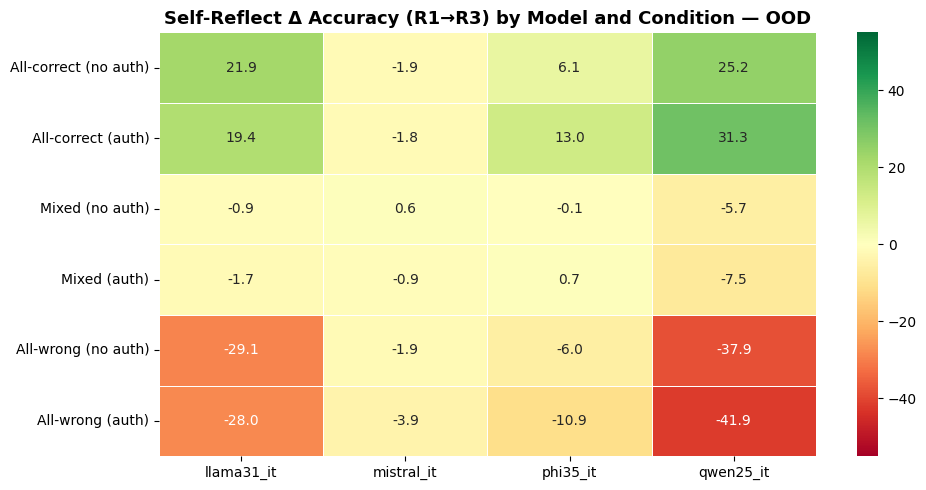

In [20]:
if combined_ood.empty:
    print("No OOD data found.")
else:
    pivot = combined_ood[combined_ood["condition"].isin(RQ1_CONDITIONS)].pivot_table(
        index="condition", columns="model", values="delta_acc")
    pivot = pivot.reindex([c for c in RQ1_CONDITIONS if c in pivot.index])

    fig, ax = plt.subplots(figsize=(max(6, 2.5*len(MODELS)), 5))
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0, vmin=-55, vmax=55,
                linewidths=0.5, ax=ax, annot_kws={"size": 10})
    ax.set_title("Self-Reflect Δ Accuracy (R1→R3) by Model and Condition — OOD", fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_yticklabels([CONDITION_LABELS.get(c, c).replace("\n", " ") for c in pivot.index], rotation=0)
    plt.tight_layout()
    plt.savefig(RQ3B_DIR / "rq3b_ood_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
